In [1]:
# Libraries & Setup
import pandas as pd
import numpy as np
import geopandas as gpd
import simpy
import random
from datetime import datetime, timedelta
import fiona
import cbsodata
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
from tqdm import tqdm
from shapely.geometry import Point
import folium
from folium import plugins
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import heapq
import bisect
from collections import Counter

In [2]:
# Paden instellen -> VERANDER NAAR EIGEN LOCATIES
path_to_gpkg = '/Users/jurre/Documents/BSc Data Science & Society/Year 2/Field Project/cbsgebiedsindelingen2016_heden/cbsgebiedsindelingen2024.gpkg' 
path_to_gtfs = '/Users/jurre/Documents/BSc Data Science & Society/Year 2/Field Project/gtfs-nl'

In [3]:
# Seed voor reproduceerbaarheid
random.seed(42)
np.random.seed(42)

In [ ]:
# Deze cel bevat alle belangrijke instellingen en parameters van de simulatie
# Pas deze waarden aan om scenario's door te rekenen

# A. Demografie & Tijdsinstellingen
SIM_DATE = "20260527"          # Dinsdag 27 mei 2026
GROEI_FACTOR = 1.00572         # Bevolkingsgroei factor (CBS dec 2024 -> apr 2026 = +0,572%; Bron: CBS Bevolkingsontwikkeling; maand en jaar)
AANDEEL_SPITSUUR_AUTO = 0.10   # Geschat percentage van het dagelijks autoverkeer dat in 1 spitsuur valt (validatie)

# B. Kosten
# Bron: Nibud/CBS gemiddeldes
KOSTEN_AUTO_PER_KM = 0.21      # Euro per kilometer
KOSTEN_OV_PER_KM = 0.20        # Euro per kilometer

# C. Gravity Model & CBS Data
BETA = 1.5                                # Vervalparameter β Gravity Model (weerstand tegen afstand)
KOLOM_PENDELAARS = 'BanenVanWerknemers_1' # CBS Dataset kolomnaam voor pendelvolume
KOLOM_AFSTAND = 'WoonWerkafstand_2'       # CBS Dataset kolomnaam voor afstand
BUURT_LAAG_NAAM = 'buurt_labelpoint' 

# D. Logit Modal Split
# Alfa parameters: Base utility/voorkeur onafhankelijk van tijd/kosten
ALPHA_AUTO = 2.0               # Hoog wegens comfort/flexibiliteit
ALPHA_OV = 0.6                 # Lager wegens wachten/overstappen
ALPHA_FIETS = 1.0
ALPHA_LOPEN = 0.5

# Bèta parameters: Gevoeligheid voor Tijd en Geld (Negatief = Straf)
BETA_TIJD = -0.05              # Elke minuut reistijd doet pijn
BETA_KOSTEN = -0.10            # Elke euro doet nog meer pijn

START_TIME = 21600             # Starttijd simulatie: 06:00 (21600 sec)

In [5]:
#  Data Importeren (CBS & Geo)
municipalities = gpd.read_file(path_to_gpkg, layer='gemeente_gegeneraliseerd')
municipalities['geometry'] = municipalities.geometry.make_valid() # Fix corrupte vlakken

gemeenten = [
    "Achtkarspelen", "Ameland", "Dantumadiel", "De Fryske Marren", 
    "Harlingen", "Heerenveen", "Leeuwarden", "Noardeast-Fryslân", 
    "Ooststellingwerf", "Opsterland", "Schiermonnikoog", "Smallingerland", 
    "Súdwest-Fryslân", "Terschelling", "Tytsjerksteradiel", "Vlieland", 
    "Waadhoeke", "Weststellingwerf"
]

Fryslân = municipalities[municipalities['statnaam'].isin(gemeenten)].copy()

# CBS Tabel 85481NED Woon-Werkverkeer in Fryslân (2024)
table_id = '85481NED'
regio_meta = pd.DataFrame(cbsodata.get_meta(table_id, 'WoonregioS'))
extra_gemeenten = ['Groningen', 'Zwolle', 'Alkmaar', 'Noordoostpolder', 'Assen', 'Noordenveld', 'Steenwijkerland', 'Westerkwartier']
alle_toegestane_gemeenten = gemeenten + extra_gemeenten
cbs_zoek_gemeenten = alle_toegestane_gemeenten + ['Groningen (gemeente)']
friesland_keys_exact = regio_meta[regio_meta['Title'].str.strip().isin(cbs_zoek_gemeenten)]['Key'].tolist()

woon_filter = " or ".join([f"WoonregioS eq '{k}'" for k in friesland_keys_exact])
werk_filter = " or ".join([f"WerkregioS eq '{k}'" for k in friesland_keys_exact])
periode_filter = "Perioden eq '2024MM12'"
full_filter = f"({woon_filter}) and ({werk_filter}) and {periode_filter}"

pendel_matrix = pd.DataFrame(cbsodata.get_data(table_id, filters=full_filter, select=['WoonregioS', 'WerkregioS', 'Perioden', 'BanenVanWerknemers_1','WoonWerkafstand_2']))

# CBS Tabel 85984NED: Kerncijfers Wijken en Buurten (2024)
df_alles = pd.DataFrame(cbsodata.get_data('85984NED'))
col_regio_type = [c for c in df_alles.columns if 'SoortRegio' in c or 'soort' in c.lower()][0]
col_code       = [c for c in df_alles.columns if 'Codering' in c or 'code' in c.lower()][0]
col_gemeente   = [c for c in df_alles.columns if 'Gemeentenaam' in c or 'gemeente' in c.lower()][0]
col_inwoners   = [c for c in df_alles.columns if 'AantalInwoners' in c or 'inwoners' in c.lower()][0]

df_buurten = df_alles[df_alles[col_regio_type].str.strip() == 'Buurt'].copy()
df_buurten['Gemeente_Lower'] = df_buurten[col_gemeente].str.lower().str.strip()
friese_gemeenten_clean = [g.lower().strip() for g in alle_toegestane_gemeenten]

df_wijkenenbuurten = df_buurten[df_buurten['Gemeente_Lower'].isin(friese_gemeenten_clean)].copy()
df_wijkenenbuurten = df_wijkenenbuurten[[col_code, 'WijkenEnBuurten', col_gemeente, col_inwoners]].rename(
    columns={col_code: 'buurt_code', 'WijkenEnBuurten': 'buurt_naam', col_gemeente: 'gemeente_naam', col_inwoners: 'aantal_inwoners'})
df_wijkenenbuurten['aantal_inwoners'] = df_wijkenenbuurten['aantal_inwoners'].fillna(0).astype(int)

# Geolocatie Buurten (GPKG)
kaarten = gpd.read_file(path_to_gpkg, layer=BUURT_LAAG_NAAM)
gpkg_code_kolom = 'statcode'
kaarten[gpkg_code_kolom] = kaarten[gpkg_code_kolom].astype(str).str.strip()
df_wijkenenbuurten['buurt_code'] = df_wijkenenbuurten['buurt_code'].astype(str).str.strip()
buurten_fryslan_gdf = kaarten.merge(df_wijkenenbuurten, left_on=gpkg_code_kolom, right_on='buurt_code', how='inner')

In [6]:
# GTFS Data & OV Haltes Filteren
routes = pd.read_csv(os.path.join(path_to_gtfs, 'routes.txt'), dtype=str)
trips = pd.read_csv(os.path.join(path_to_gtfs, 'trips.txt'), dtype=str)
stop_times = pd.read_csv(os.path.join(path_to_gtfs, 'stop_times.txt'), dtype=str)
stops = pd.read_csv(os.path.join(path_to_gtfs, 'stops.txt'), dtype=str)
calendar_dates = pd.read_csv(os.path.join(path_to_gtfs, 'calendar_dates.txt'))

ov_routes = routes[routes['route_type'].isin([2, 3, 700, 701, 702, 703, 704, '2', '3', '700'])]['route_id'].unique()
ov_trips = trips[trips['route_id'].isin(ov_routes)]['trip_id'].unique()
ov_stop_times = stop_times[stop_times['trip_id'].isin(ov_trips)].dropna(subset=['arrival_time'])
ov_stations = stops[stops['stop_id'].isin(ov_stop_times['stop_id'].unique())]

ov_stations_gdf = gpd.GeoDataFrame(ov_stations, geometry=gpd.points_from_xy(ov_stations.stop_lon.astype(float), ov_stations.stop_lat.astype(float)), crs="EPSG:4326")
Fryslân = Fryslân.to_crs(crs="EPSG:4326")

friese_ov_stations_puur = gpd.sjoin(ov_stations_gdf, Fryslân, predicate='within')
friese_station_ids_spatial = set(friese_ov_stations_puur['stop_id'].tolist())

extra_bus_lijnen = ['315', '324', '350', '39', '133', '139', '101', '84', '104', '18', '217']
extra_routes = routes[(routes['route_short_name'].isin(extra_bus_lijnen)) | (routes['agency_id'].isin(['WPD', 'DOEKSEN'])) | ((routes['route_type'].isin([2, '2'])) & (routes['route_long_name'].str.contains('Zwolle|Groningen|Leeuwarden', na=False)))]['route_id'].astype(str)
extra_trips = trips[trips['route_id'].astype(str).isin(extra_routes)]['trip_id'].astype(str)
extra_stops = stop_times[stop_times['trip_id'].astype(str).isin(extra_trips)]['stop_id'].unique()

alle_ov_stations = ov_stations_gdf[ov_stations_gdf['stop_id'].isin(friese_station_ids_spatial.union(extra_stops))]
friese_ov_stations = alle_ov_stations.copy()

train_routes = routes[routes['route_type'].isin([2, '2'])]['route_id']
train_trips = trips[trips['route_id'].isin(train_routes)]['trip_id']
train_stop_ids = stop_times[stop_times['trip_id'].isin(train_trips)]['stop_id'].unique()

friese_train_stations = friese_ov_stations[friese_ov_stations['stop_id'].isin(train_stop_ids)].copy()
friese_bus_stations = friese_ov_stations[~friese_ov_stations['stop_id'].isin(train_stop_ids)].copy()

if not friese_train_stations.empty:
    friese_train_stations['geometry'] = friese_train_stations.geometry.make_valid()
    bus_gdf_metric = friese_bus_stations.to_crs("EPSG:28992")
    train_gdf_metric = friese_train_stations.to_crs("EPSG:28992")
    train_gdf_metric['geometry'] = train_gdf_metric.geometry.buffer(250)
    
    bus_gdf_metric = bus_gdf_metric.drop(columns=['index_right', 'index_left'], errors='ignore')
    train_gdf_metric = train_gdf_metric.drop(columns=['index_right', 'index_left'], errors='ignore')
    
    joined = gpd.sjoin(bus_gdf_metric, train_gdf_metric[['stop_name', 'geometry']], how='left', predicate='intersects')
    joined['stop_name'] = joined['stop_name_right'].fillna(joined['stop_name_left'])
    updated_bus = joined.drop(columns=['index_right', 'stop_name_left', 'stop_name_right']).to_crs("EPSG:4326")
    friese_ov_stations = pd.concat([friese_train_stations, updated_bus]).drop_duplicates(subset=['stop_id'])

In [7]:
# OSMnx Netwerk Ophalen
ox.settings.log_console = False

# Definieer de bestandsnamen voor de cache
cache_file_drive = "netwerk_auto_friesland_provincies.graphml"
cache_file_bike = "netwerk_fiets_friesland.graphml"

# Autonetwerk (G_drive)
if os.path.exists(cache_file_drive):
    G_drive = ox.load_graphml(cache_file_drive)
else:    
    # Friesland hoofdwegennetwerk opbouwen
    G_fryslan_raw = ox.graph_from_place({"state": "Friesland", "country": "Netherlands"}, network_type="drive")
    largest_cc = max(nx.strongly_connected_components(G_fryslan_raw), key=len)
    G_fryslan = G_fryslan_raw.subgraph(largest_cc).copy()
    
    custom_filter = '["highway"~"motorway|motorway_link|trunk|trunk_link|primary|primary_link|secondary|secondary_link"]'
    G_provincies = ox.graph_from_place([
        {'state': 'Friesland', 'country': 'Netherlands'},
        {'state': 'Groningen', 'country': 'Netherlands'},
        {'state': 'Drenthe', 'country': 'Netherlands'},
        {'state': 'Overijssel', 'country': 'Netherlands'},
        {'state': 'Flevoland', 'country': 'Netherlands'},
        {'state': 'Noord-Holland', 'country': 'Netherlands'}
    ], custom_filter=custom_filter)
    
    # Definitief Car Netwerk samenvoegen
    G_drive = nx.compose(G_fryslan, G_provincies)
    G_drive = ox.add_edge_speeds(G_drive)
    G_drive = ox.add_edge_travel_times(G_drive)
    
    # Opslaan voor de volgende keer!
    ox.save_graphml(G_drive, cache_file_drive)
    print(f"Autonetwerk gedownload en opgeslagen als '{cache_file_drive}'.")

# Fietsnetwerk (G_bike)
if os.path.exists(cache_file_bike):
    G_bike = ox.load_graphml(cache_file_bike)
else:    
    # Definitief Bike Netwerk
    G_bike = ox.graph_from_place("Friesland, Netherlands", network_type="bike")
    G_bike = ox.add_edge_speeds(G_bike, fallback=15)
    G_bike = ox.add_edge_travel_times(G_bike)
    
    # Opslaan voor de volgende keer!
    ox.save_graphml(G_bike, cache_file_bike)
    print(f"Fietsnetwerk gedownload en opgeslagen als '{cache_file_bike}'.")

In [8]:
# Gravity Model & Modal Split
df_pendel = pendel_matrix.copy()
df_pendel['WoonregioS'] = df_pendel['WoonregioS'].str.replace(' (gemeente)', '', regex=False).str.strip()
df_pendel['WerkregioS'] = df_pendel['WerkregioS'].str.replace(' (gemeente)', '', regex=False).str.strip()
df_pendel = df_pendel[((df_pendel['WoonregioS'].isin(gemeenten)) & (df_pendel['WerkregioS'].isin(alle_toegestane_gemeenten))) | ((df_pendel['WoonregioS'].isin(alle_toegestane_gemeenten)) & (df_pendel['WerkregioS'].isin(gemeenten)))]
df_pendel[KOLOM_PENDELAARS] = df_pendel[KOLOM_PENDELAARS] * 1000 

massa_oorsprong = df_pendel.groupby('WoonregioS')[KOLOM_PENDELAARS].sum().reset_index().rename(columns={'WoonregioS': 'Gemeente', KOLOM_PENDELAARS: 'Y_i'})
massa_bestemming = df_pendel.groupby('WerkregioS')[KOLOM_PENDELAARS].sum().reset_index().rename(columns={'WerkregioS': 'Gemeente', KOLOM_PENDELAARS: 'Y_j'})

gravity_model = df_pendel[['WoonregioS', 'WerkregioS', KOLOM_AFSTAND, KOLOM_PENDELAARS]].copy().rename(columns={KOLOM_AFSTAND: 'Afstand_km', KOLOM_PENDELAARS: 'Werkelijke_Pendel'})
gravity_model = gravity_model.merge(massa_oorsprong, left_on='WoonregioS', right_on='Gemeente', how='inner').drop(columns=['Gemeente'])
gravity_model = gravity_model.merge(massa_bestemming, left_on='WerkregioS', right_on='Gemeente', how='inner').drop(columns=['Gemeente'])

gravity_model['Afstand_km'] = pd.to_numeric(gravity_model['Afstand_km'], errors='coerce')
gravity_model = gravity_model.dropna(subset=['Afstand_km'])
gravity_model = gravity_model[gravity_model['Afstand_km'] > 0].copy()

gravity_model['Theoretische_Interactie'] = ((gravity_model['Y_i'] * gravity_model['Y_j']) / (gravity_model['Afstand_km'] ** BETA))
schaalfactor = gravity_model['Werkelijke_Pendel'].sum() / gravity_model['Theoretische_Interactie'].sum()

gravity_model['DUS_Reizigers_Totaal'] = gravity_model['Werkelijke_Pendel']
fallback = (gravity_model['Theoretische_Interactie'] * schaalfactor).round().astype(int)
gravity_model.loc[(gravity_model['DUS_Reizigers_Totaal'].isnull()) | (gravity_model['DUS_Reizigers_Totaal'] == 0), 'DUS_Reizigers_Totaal'] = fallback

# Hardcode Groningen volume
gravity_model.loc[(gravity_model['WoonregioS'].str.contains('Leeuwarden')) & (gravity_model['WerkregioS'].str.contains('Groningen')), 'DUS_Reizigers_Totaal'] = 15000
gravity_model.loc[(gravity_model['WoonregioS'].str.contains('Groningen')) & (gravity_model['WerkregioS'].str.contains('Leeuwarden')), 'DUS_Reizigers_Totaal'] = 15000

# Reistijden ophalen uit de G_drive/G_bike netwerken
fryslan_copy = Fryslân.to_crs(epsg=28992).copy()
fryslan_copy['centroid'] = fryslan_copy.geometry.centroid
centroids_wgs84 = fryslan_copy['centroid'].to_crs(epsg=4326)

gemeente_nodes_car, gemeente_nodes_bike = {}, {}
for statnaam, point in zip(fryslan_copy['statnaam'], centroids_wgs84):
    gemeente_nodes_car[statnaam] = ox.distance.nearest_nodes(G_drive, X=point.x, Y=point.y)
    gemeente_nodes_bike[statnaam] = ox.distance.nearest_nodes(G_bike, X=point.x, Y=point.y)

externe_gemeenten = set(gravity_model['WoonregioS'].unique()).union(set(gravity_model['WerkregioS'].unique())) - set(fryslan_copy['statnaam'])
for gem in externe_gemeenten:
    try:
        lat, lon = ox.geocode(gem.strip() + ", Netherlands")
        gemeente_nodes_car[gem] = ox.distance.nearest_nodes(G_drive, X=lon, Y=lat)
        gemeente_nodes_bike[gem] = ox.distance.nearest_nodes(G_bike, X=lon, Y=lat)
    except: pass

reistijden_auto, reistijden_fiets = [], []

for row in tqdm(list(gravity_model.itertuples()), desc="OD Reistijden Berekenen"):
    woon, werk = row.WoonregioS.strip(), row.WerkregioS.strip()
    tt_car, tt_bike = np.nan, np.nan
    if woon in gemeente_nodes_car and werk in gemeente_nodes_car:
        try: tt_car = nx.shortest_path_length(G_drive, gemeente_nodes_car[woon], gemeente_nodes_car[werk], weight='travel_time') / 60.0
        except nx.NetworkXNoPath: pass
    if woon in gemeente_nodes_bike and werk in gemeente_nodes_bike:
        try: tt_bike = nx.shortest_path_length(G_bike, gemeente_nodes_bike[woon], gemeente_nodes_bike[werk], weight='travel_time') / 60.0
        except nx.NetworkXNoPath: pass
    reistijden_auto.append(tt_car)
    reistijden_fiets.append(tt_bike)

gravity_model['Reistijd_Auto_min'] = reistijden_auto
gravity_model['Reistijd_Fiets_min'] = reistijden_fiets

# Logit Modal Split
modal_split = gravity_model.copy()
modal_split['Kosten_Auto'] = modal_split['Afstand_km'] * KOSTEN_AUTO_PER_KM
modal_split['Tijd_Auto'] = modal_split['Reistijd_Auto_min'].fillna((modal_split['Afstand_km'] / 80.0) * 60)
modal_split['Kosten_Fiets'] = 0.0
modal_split['Tijd_Fiets'] = modal_split['Reistijd_Fiets_min'].fillna((modal_split['Afstand_km'] / 15.0) * 60)
modal_split.loc[modal_split['Afstand_km'] > 15, 'Tijd_Fiets'] += 999 
modal_split['Kosten_Lopen'] = 0.0
modal_split['Tijd_Lopen'] = (modal_split['Afstand_km'] / 5.0) * 60 
modal_split.loc[modal_split['Afstand_km'] > 4, 'Tijd_Lopen'] += 9999 
modal_split['Kosten_OV'] = modal_split['Afstand_km'] * KOSTEN_OV_PER_KM
modal_split['Tijd_OV'] = (modal_split['Afstand_km'] / 70.0) * 60 + 10
modal_split.loc[(modal_split['WoonregioS'].str.contains('Leeuwarden')) & (modal_split['WerkregioS'].str.contains('Groningen')), 'Tijd_OV'] = 35
modal_split.loc[(modal_split['WoonregioS'].str.contains('Groningen')) & (modal_split['WerkregioS'].str.contains('Leeuwarden')), 'Tijd_OV'] = 35 

modal_split['V_Auto'] = np.clip(ALPHA_AUTO + (BETA_TIJD * modal_split['Tijd_Auto']) + (BETA_KOSTEN * modal_split['Kosten_Auto']), -100, None)
modal_split['V_OV'] = np.clip(ALPHA_OV + (BETA_TIJD * modal_split['Tijd_OV']) + (BETA_KOSTEN * modal_split['Kosten_OV']), -100, None)
modal_split['V_Fiets'] = np.clip(ALPHA_FIETS + (BETA_TIJD * modal_split['Tijd_Fiets']) + (BETA_KOSTEN * modal_split['Kosten_Fiets']), -100, None)
modal_split['V_Lopen'] = np.clip(ALPHA_LOPEN + (BETA_TIJD * modal_split['Tijd_Lopen']) + (BETA_KOSTEN * modal_split['Kosten_Lopen']), -100, None)

som_exp = np.exp(modal_split['V_Auto']) + np.exp(modal_split['V_OV']) + np.exp(modal_split['V_Fiets']) + np.exp(modal_split['V_Lopen'])
modal_split['P_Auto'] = np.exp(modal_split['V_Auto']) / som_exp
modal_split['P_OV'] = np.exp(modal_split['V_OV']) / som_exp
modal_split['P_Fiets'] = np.exp(modal_split['V_Fiets']) / som_exp
modal_split['P_Lopen'] = np.exp(modal_split['V_Lopen']) / som_exp

modal_split['Forenzen_Auto'] = (modal_split['DUS_Reizigers_Totaal'] * modal_split['P_Auto']).fillna(0).round().astype(int)
modal_split['Forenzen_OV'] = (modal_split['DUS_Reizigers_Totaal'] * modal_split['P_OV']).fillna(0).round().astype(int)

top_ov = modal_split[modal_split['WoonregioS'] != modal_split['WerkregioS']].sort_values(by='Forenzen_OV', ascending=False)

OD Reistijden Berekenen: 100%|██████████| 547/547 [01:18<00:00,  6.93it/s]


In [9]:
# SimPy Generatie & Routeplanning
print("5. Passagiers genereren en stations koppelen...")
simulatie_vraag = top_ov.copy()
simulatie_vraag['Forenzen_OV'] = (simulatie_vraag['Forenzen_OV'] * GROEI_FACTOR).round().astype(int)
simulatie_vraag['Forenzen_Auto'] = (simulatie_vraag['Forenzen_Auto'] * GROEI_FACTOR).round().astype(int)

# Dichtstbijzijnde stations berekenen voor passengier spawn points
stations_copy = friese_ov_stations.to_crs(epsg=28992)
buurten_copy = buurten_fryslan_gdf.to_crs(epsg=28992)
buurten_copy['Nearest_Station_Name'] = buurten_copy.geometry.apply(lambda geom: stations_copy.loc[stations_copy.geometry.distance(geom).idxmin(), 'stop_name'])

station_weights = buurten_copy.groupby(['gemeente_naam', 'Nearest_Station_Name'])['aantal_inwoners'].sum().reset_index()
gemeente_totals = station_weights.groupby('gemeente_naam')['aantal_inwoners'].sum().reset_index().rename(columns={'aantal_inwoners': 'totaal_gemeente_inwoners'})
station_weights = station_weights.merge(gemeente_totals, on='gemeente_naam')
station_weights['totaal_gemeente_inwoners'] = station_weights['totaal_gemeente_inwoners'].replace(0, 1) 
station_weights['Station_Weight'] = station_weights['aantal_inwoners'] / station_weights['totaal_gemeente_inwoners']

# Genereer OV passagiers
passagiers_lijst = []
for row in simulatie_vraag[simulatie_vraag['Forenzen_OV'] > 0].itertuples():
    origin, dest, totaal_ov = row.WoonregioS.strip(), row.WerkregioS.strip(), row.Forenzen_OV
    orig_stations = station_weights[station_weights['gemeente_naam'] == origin]
    dest_stations = station_weights[station_weights['gemeente_naam'] == dest]
    if orig_stations.empty or dest_stations.empty: continue
        
    for _ in range(totaal_ov):
        orig_row = orig_stations.sample(n=1, weights='Station_Weight').iloc[0]
        dest_row = dest_stations.sample(n=1, weights='Station_Weight').iloc[0]
        
        rand_heen = random.random()
        if rand_heen <= 0.70: spawn_heen = max(25200, min(32400, int(np.random.normal(27900, 1800))))
        elif rand_heen <= 0.95: spawn_heen = random.randint(32400, 57600)
        else: spawn_heen = random.randint(57600, 64800)
            
        passagiers_lijst.append({'Passagier_ID': len(passagiers_lijst)+1, 'Start_Station': orig_row['Nearest_Station_Name'], 'Eind_Station': dest_row['Nearest_Station_Name'], 'Spawn_Tijd_Sec': spawn_heen})
        
        rand_terug = random.random()
        if rand_terug <= 0.05: spawn_terug = random.randint(25200, 32400)
        elif rand_terug <= 0.30: spawn_terug = random.randint(32400, 57600)
        else: spawn_terug = max(57600, min(66600, int(np.random.normal(61200, 1800))))
        spawn_terug = min(86399, max(spawn_heen + 14400, spawn_terug))
            
        passagiers_lijst.append({'Passagier_ID': len(passagiers_lijst)+1, 'Start_Station': dest_row['Nearest_Station_Name'], 'Eind_Station': orig_row['Nearest_Station_Name'], 'Spawn_Tijd_Sec': spawn_terug})

if len(passagiers_lijst) > 0:
    df_passagiers = pd.DataFrame(passagiers_lijst).sort_values(by='Spawn_Tijd_Sec').reset_index(drop=True)
else:
    df_passagiers = pd.DataFrame(columns=['Passagier_ID', 'Start_Station', 'Eind_Station', 'Spawn_Tijd_Sec'])

# SimPy Voorbereidingen
def time_to_seconds(t_str):
    if pd.isna(t_str): return 0
    h, m, s = map(int, str(t_str).split(':'))
    return h * 3600 + m * 60 + s

ov_routes_df = routes[routes['route_type'].isin(['2', '3', '700', '701', '702', '703', '704'])]
actieve_services = calendar_dates[(calendar_dates['date'] == int(SIM_DATE)) & (calendar_dates['exception_type'] == 1)]['service_id'].astype(str).tolist()
actieve_trips = trips[(trips['service_id'].isin(actieve_services)) & (trips['route_id'].isin(ov_routes_df['route_id']))]
actieve_trips = actieve_trips.merge(ov_routes_df[['route_id', 'agency_id', 'route_type']], on='route_id', how='left')

def bepalen_capaciteit(row):
    r_type, agency = str(row['route_type']), str(row['agency_id']).upper()
    if r_type in ['3', '700']: return 60 
    return 400 if 'NS' in agency else 150 if 'ARRIVA' in agency else 60
actieve_trips['Capaciteit'] = actieve_trips.apply(bepalen_capaciteit, axis=1)

friese_stops = friese_ov_stations['stop_id'].astype(str).tolist()
actieve_st = stop_times[stop_times['trip_id'].isin(actieve_trips['trip_id'])]
valide_trips = actieve_st[actieve_st['stop_id'].isin(friese_stops)]['trip_id'].value_counts()
valide_trips = valide_trips[valide_trips > 1].index.tolist()

uiteindelijke_st = actieve_st[(actieve_st['trip_id'].isin(valide_trips)) & (actieve_st['stop_id'].isin(friese_stops))].copy()
uiteindelijke_st['arrival_sec'] = uiteindelijke_st['arrival_time'].apply(time_to_seconds)
uiteindelijke_st['departure_sec'] = uiteindelijke_st['departure_time'].apply(time_to_seconds)
stoptimes_simulatie = uiteindelijke_st.sort_values(by=['trip_id', 'stop_sequence']).merge(friese_ov_stations[['stop_id', 'stop_name']], on='stop_id', how='left')
actieve_trips_dict = actieve_trips.set_index('trip_id')['Capaciteit'].to_dict()

station_departures, station_departures_times = {}, {}
for trip_id, stops_df in stoptimes_simulatie.groupby('trip_id'):
    st_lijst = stops_df.sort_values('stop_sequence').to_dict('records')
    for idx in range(len(st_lijst) - 1):
        u, v = st_lijst[idx]['stop_name'], st_lijst[idx+1]['stop_name']
        dep_u, arr_v = st_lijst[idx]['departure_sec'], st_lijst[idx+1]['arrival_sec']
        if u not in station_departures: station_departures[u] = []
        station_departures[u].append((dep_u, arr_v, v, trip_id))

for u in station_departures:
    station_departures[u].sort(key=lambda x: x[0])
    station_departures_times[u] = [x[0] for x in station_departures[u]]

class DUS_Simulatie:
    def __init__(self, env, stations_list):
        self.env = env
        self.stations = {s: [] for s in stations_list}
        self.log_data = [] 
        
    def log(self, tijd, event_type, station, passagiers_aantal, trein_id=None, trein_bezetting=None, capaciteit=None):
        self.log_data.append({'Tijd_Sec': tijd, 'Event': event_type, 'Station': station, 'Aantal_Passagiers': passagiers_aantal, 'Trein_ID': trein_id, 'Trein_Bezetting': trein_bezetting, 'Trein_Capaciteit': capaciteit})

def time_dependent_dijkstra(start_station, eind_station, start_time):
    pq = [(start_time, start_station)] 
    earliest_arrival = {start_station: start_time}
    parent = {}
    while pq:
        time, u = heapq.heappop(pq)
        if time > earliest_arrival.get(u, float('inf')): continue
        if u == eind_station: break
        deps = station_departures.get(u, [])
        times = station_departures_times.get(u, [])
        if not deps: continue
        idx = bisect.bisect_left(times, time)
        for i in range(idx, len(deps)):
            dep_time, arr_time, v, trip_id = deps[i]
            if arr_time < earliest_arrival.get(v, float('inf')):
                earliest_arrival[v] = arr_time
                parent[v] = u
                heapq.heappush(pq, (arr_time, v))
    if eind_station not in earliest_arrival: return []
    path, curr = [eind_station], eind_station
    while curr != start_station:
        curr = parent[curr]
        path.append(curr)
    path.reverse()
    clean_path = [path[0]]
    for p in path[1:]:
        if p != clean_path[-1]: clean_path.append(p)
    return clean_path

def passagier_generator(env, sim, passagiers_df):
    passagiers = passagiers_df.to_dict('records')
    route_cache = {} # OPTIMALISATIE: Cache voor Dijkstra routes!
    
    for reiziger in passagiers:
        wachttijd = reiziger['Spawn_Tijd_Sec'] - env.now
        if wachttijd > 0: yield env.timeout(wachttijd)
            
        start_station, eind_station = reiziger['Start_Station'], reiziger['Eind_Station']
        if start_station == eind_station: continue
        
        # Check cache voordat we Dijkstra runnen (sleutel: Start, Eind, Vertrektijd)
        cache_key = (start_station, eind_station, env.now)
        if cache_key in route_cache:
            route_plan = route_cache[cache_key]
        else:
            route_plan = time_dependent_dijkstra(start_station, eind_station, env.now)
            route_cache[cache_key] = route_plan
        
        if not route_plan:
            sim.log(env.now, 'Geen Route Mogelijk', start_station, 1)
            continue 
            
        if start_station in sim.stations:
            sim.stations[start_station].append({'id': reiziger['Passagier_ID'], 'route_plan': route_plan, 'bestemming': eind_station})
            sim.log(env.now, 'Aankomst Perron', start_station, len(sim.stations[start_station]))

def trein_proces(env, sim, trip_id, capaciteit, haltes_df):
    passagiers_in_trein = []
    haltes = haltes_df[haltes_df['trip_id'] == trip_id].sort_values(by='stop_sequence').to_dict('records')
    halte_names = [h['stop_name'] for h in haltes]
    
    for i, halte in enumerate(haltes):
        station_naam, aankomst, vertrek = halte['stop_name'], halte['arrival_sec'], halte['departure_sec']
        
        rijtijd = aankomst - env.now
        if rijtijd > 0: yield env.timeout(rijtijd)
            
        uitstappers = [p for p in passagiers_in_trein if p.get('current_doel') == station_naam]
        passagiers_in_trein = [p for p in passagiers_in_trein if p.get('current_doel') != station_naam]
        
        if len(uitstappers) > 0:
            sim.log(env.now, 'Uitstappen', station_naam, len(uitstappers), trip_id, len(passagiers_in_trein), capaciteit)
            bestemming_bereikt = sum(1 for p in uitstappers if p['bestemming'] == station_naam)
            for p in uitstappers:
                if p['bestemming'] != station_naam and station_naam in sim.stations:
                    sim.stations[station_naam].append(p)
                    sim.log(env.now, 'Overstap Wachtrij', station_naam, 1)
            if bestemming_bereikt > 0: sim.log(env.now, 'Aankomst Bestemming', station_naam, bestemming_bereikt)
                
        wachttijd = vertrek - env.now
        if wachttijd > 0: yield env.timeout(wachttijd) 
            
        if station_naam in sim.stations:
            wachtrij, rest_haltes_set = sim.stations[station_naam], set(halte_names[i+1:])
            wachtrij_over, instappers = [], 0
            
            for p in wachtrij:
                route_plan = p['route_plan']
                try: volgende_station = route_plan[route_plan.index(station_naam) + 1]
                except (ValueError, IndexError): 
                    wachtrij_over.append(p)
                    continue
                
                if volgende_station in rest_haltes_set and len(passagiers_in_trein) < capaciteit:
                    rest_route = route_plan[route_plan.index(station_naam) + 1:]
                    p['current_doel'] = next((s for s in reversed(rest_route) if s in rest_haltes_set), None)
                    passagiers_in_trein.append(p)
                    instappers += 1
                else:
                    wachtrij_over.append(p) 
                    
            sim.stations[station_naam] = wachtrij_over
            if instappers > 0: sim.log(env.now, 'Instappen', station_naam, instappers, trip_id, len(passagiers_in_trein), capaciteit)

print("SimPy OV Simulatie Starten...")
env = simpy.Environment(initial_time=START_TIME)
sim = DUS_Simulatie(env, friese_ov_stations['stop_name'].unique().tolist())
env.process(passagier_generator(env, sim, df_passagiers))

for trip_id in valide_trips:
    env.process(trein_proces(env, sim, trip_id, actieve_trips_dict.get(trip_id, 300), stoptimes_simulatie))

env.run()
log_df = pd.DataFrame(sim.log_data)

5. Passagiers genereren en stations koppelen...
SimPy OV Simulatie Starten...


In [10]:
# Auto Simulatie
buurten_wgs84 = buurten_fryslan_gdf.to_crs(epsg=4326).copy()

gemeente_buurten = {}
for row in buurten_wgs84.itertuples():
    gem, code, pop = row.gemeente_naam.strip(), row.buurt_code, row.aantal_inwoners
    if pop > 0:
        if gem not in gemeente_buurten: gemeente_buurten[gem] = []
        gemeente_buurten[gem].append({'code': code, 'pop': pop, 'point': row.geometry.centroid})

buurt_nodes_car = {}
relevante_gemeenten = set(simulatie_vraag['WoonregioS'].unique()).union(set(simulatie_vraag['WerkregioS'].unique()))
for gem, buurten in gemeente_buurten.items():
    if gem in relevante_gemeenten:
        for b in buurten: buurt_nodes_car[b['code']] = ox.distance.nearest_nodes(G_drive, X=b['point'].x, Y=b['point'].y)

edge_counts = Counter()
auto_routes_df = simulatie_vraag[simulatie_vraag['Forenzen_Auto'] > 0]

for row in tqdm(list(auto_routes_df.itertuples()), desc='Simuleren autoverkeer'):
    woon, werk, aantal_autos = row.WoonregioS.strip(), row.WerkregioS.strip(), int(round(row.Forenzen_Auto))
    if aantal_autos > 0 and woon in gemeente_buurten and werk in gemeente_buurten:
        aantal_paden = min(aantal_autos, 5) 
        autos_per_pad, rest_autos = aantal_autos // aantal_paden, aantal_autos % aantal_paden
        woon_buurten, werk_buurten = gemeente_buurten[woon], gemeente_buurten[werk]
        woon_weights, werk_weights = [b['pop'] for b in woon_buurten], [b['pop'] for b in werk_buurten]
        
        if sum(woon_weights) == 0 or sum(werk_weights) == 0: continue
            
        for p in range(aantal_paden):
            source_b = random.choices(woon_buurten, weights=woon_weights, k=1)[0]
            target_b = random.choices(werk_buurten, weights=werk_weights, k=1)[0]
            source_node, target_node = buurt_nodes_car.get(source_b['code']), buurt_nodes_car.get(target_b['code'])
            flow = autos_per_pad + (rest_autos if p == 0 else 0)
            
            if source_node and target_node and source_node != target_node:
                try:
                    path = nx.shortest_path(G_drive, source=source_node, target=target_node, weight='length')
                    # Sneller tellen via zip generator en Python Counter
                    edges_in_path = list(zip(path[:-1], path[1:]))
                    for edge in edges_in_path:
                        edge_counts[edge] += flow
                except nx.NetworkXNoPath:
                    pass

export_folder = 'Simulatie_Resultaten'
os.makedirs(export_folder, exist_ok=True)

auto_export_data = []
for (u, v), flow in edge_counts.items():
    edge_data = G_drive.get_edge_data(u, v)[0]
    name = edge_data.get('name', 'Onbekende Weg')
    name = name[0] if isinstance(name, list) else name
    speed = edge_data.get('maxspeed', 50)
    speed = speed[0] if isinstance(speed, list) else speed
    auto_export_data.append({'Van_Node': u, 'Naar_Node': v, 'Straatnaam': name, 'Lengte_m': round(edge_data.get('length', 0), 1), 'Snelheid_kmu': speed, 'Volume_Autos': flow})
        
pd.DataFrame(auto_export_data).to_csv(os.path.join(export_folder, 'auto_edge_counts.csv'), index=False)
log_df.to_csv(os.path.join(export_folder, 'OV_Ruwe_Logs.csv'), index=False)
simulatie_vraag.to_csv(os.path.join(export_folder, 'Totale_Vraag_Modal_Split.csv'), index=False)

if not log_df.empty:
    station_activity = log_df[log_df['Event'].isin(['Instappen', 'Uitstappen'])].groupby('Station')['Aantal_Passagiers'].sum().reset_index()
    station_activity.to_csv(os.path.join(export_folder, 'ov_station_drukte.csv'), index=False)

Simuleren autoverkeer: 100%|██████████| 482/482 [00:52<00:00,  9.23it/s]


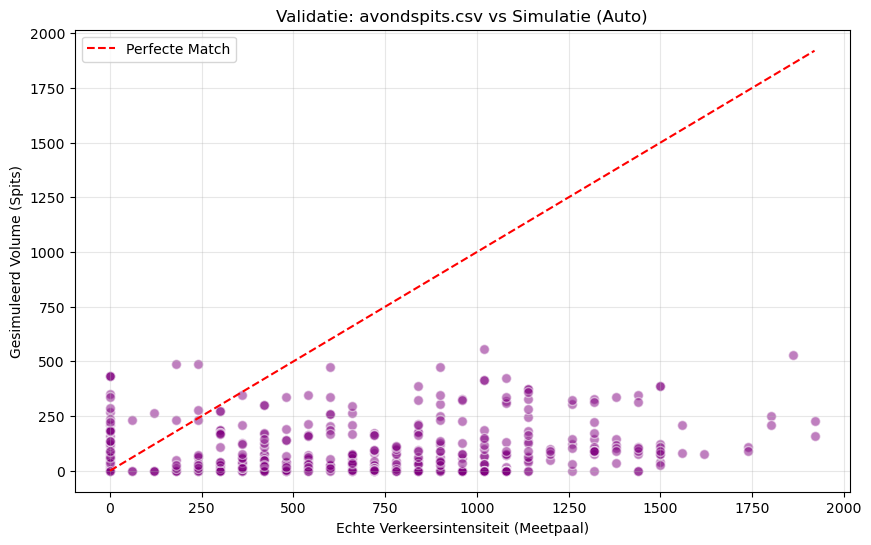

Correlatiecoëfficiënt (Pearson r): 0.16


In [11]:
# Validatie (Auto-)Simulatie met avondspits.csv
if os.path.exists('avondspits.csv'):
    avondspits_df = pd.read_csv('avondspits.csv')
    y_true = []
    y_pred = []
    
    for row in avondspits_df.itertuples():
        # Zoek dichtstbijzijnde edge in G_drive
        u, v, key = ox.distance.nearest_edges(G_drive, X=row.longitude, Y=row.latitude)
        # Tel volume in beide richtingen op
        sim_flow = edge_counts.get((u, v), 0) + edge_counts.get((v, u), 0)
        sim_flow_spits = sim_flow * AANDEEL_SPITSUUR_AUTO
        
        y_true.append(row.verkeersintensiteit)
        y_pred.append(sim_flow_spits)
                
    # Plot
    plt.figure(figsize=(10,6))
    plt.scatter(y_true, y_pred, alpha=0.5, color='purple', edgecolors='white', s=50)
        
    # Lijn voor perfecte correlatie
    max_val = max(max(y_true), max(y_pred))
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfecte Match')
        
    plt.title('Validatie: avondspits.csv vs Simulatie (Auto)')
    plt.xlabel('Echte Verkeersintensiteit (Meetpaal)')
    plt.ylabel('Gesimuleerd Volume (Spits)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
        
    # Correlatie Berekenen
    cor = np.corrcoef(y_true, y_pred)[0,1]
    print(f"Correlatiecoëfficiënt (Pearson r): {cor:.2f}")

In [12]:
# Folium Interactieve Kaart
m = folium.Map(location=[53.164164, 5.781754], zoom_start=10, tiles='cartodbdark_matter')

# OV Stations (Bubbels)
fg_stations = folium.FeatureGroup(name="Station Drukte (Bubbels)")
if not log_df.empty:
    station_coords = friese_ov_stations[['stop_name', 'stop_lat', 'stop_lon']].drop_duplicates(subset=['stop_name'])
    st_act = log_df[log_df['Event'].isin(['Instappen', 'Uitstappen'])].groupby('Station')['Aantal_Passagiers'].sum().reset_index()
    st_act = st_act.merge(station_coords, left_on='Station', right_on='stop_name', how='inner')
    
    if not st_act.empty:
        p90, p70, p40 = np.percentile(st_act['Aantal_Passagiers'], [90, 70, 40])
        for row in st_act.itertuples():
            pax = row.Aantal_Passagiers
            radius = min(18, max(3, np.log1p(pax) * 2)) # Logaritmische schaal
            if pax >= p90: color = '#ff0000'
            elif pax >= p70: color = '#ff9900'
            elif pax >= p40: color = '#ffff00'
            else: color = '#00ff00'
                
            folium.CircleMarker(
                location=[float(row.stop_lat), float(row.stop_lon)], radius=radius,
                popup=f"{row.Station}: {row.Aantal_Passagiers} in/uitstappers",
                color=color, fill=True, fill_color=color, fill_opacity=0.6, weight=1
            ).add_to(fg_stations)
m.add_child(fg_stations)

# OV Pendelstromen (Top 100 AntPaths)
fg_flows = folium.FeatureGroup(name="OV Pendelstromen (Top 100)")
top_flows = simulatie_vraag.sort_values('Forenzen_OV', ascending=False).head(100)

DUS_regios = municipalities[municipalities['statnaam'].isin(alle_toegestane_gemeenten)].copy()
DUS_copy = DUS_regios.to_crs(epsg=28992)
DUS_copy['centroid'] = DUS_copy.geometry.centroid
DUS_centroids_wgs84 = DUS_copy['centroid'].to_crs(epsg=4326)
gemeente_coords = {statnaam.strip(): (point.y, point.x) for statnaam, point in zip(DUS_copy['statnaam'], DUS_centroids_wgs84)}

for row in top_flows.itertuples():
    woon, werk, passagiers = row.WoonregioS.strip(), row.WerkregioS.strip(), row.Forenzen_OV
    if passagiers > 0 and woon in gemeente_coords and werk in gemeente_coords:
        weight = min(8, max(2, passagiers / 50))
        plugins.AntPath(
            locations=[gemeente_coords[woon], gemeente_coords[werk]],
            popup=f"{woon} -> {werk}: {passagiers} reizigers",
            color="#00e5ff", pulse_color="#ffffff", weight=weight, delay=800, dash_array=[15, 30]
        ).add_to(fg_flows)
m.add_child(fg_flows)

# Auto Simulatie (Wegennetwerk)
fg_auto = folium.FeatureGroup(name="Gesimuleerd Autoverkeer (Top Wegen)")
if len(edge_counts) > 0:
    max_flow = max(edge_counts.values())
    norm = mcolors.LogNorm(vmin=1, vmax=max_flow)
    cmap = plt.get_cmap('plasma') # Deprecation warning gefixt
        
    for (u, v), flow in edge_counts.items():
        if flow > 0:
            lat_u, lon_u = G_drive.nodes[u]['y'], G_drive.nodes[u]['x']
            lat_v, lon_v = G_drive.nodes[v]['y'], G_drive.nodes[v]['x']
            color = mcolors.to_hex(cmap(norm(flow)))
            weight = min(max((flow / max_flow) * 15, 3), 12)
            
            folium.PolyLine(
                locations=[(lat_u, lon_u), (lat_v, lon_v)],
                color=color, weight=weight, opacity=0.8,
                tooltip=f"Verkeersvolume: {flow} auto's",
                popup=folium.Popup(f"<b>Gesimuleerd Volume:</b><br>{flow} auto's op dit wegsegment", max_width=250)
            ).add_to(fg_auto)
m.add_child(fg_auto)

folium.LayerControl().add_to(m)
map_path = os.path.join(export_folder, "Friesland_Simulatie_Map.html")
m.save(map_path)
print(f"Map (OV + Auto) opgeslagen als: {map_path}")

Map (OV + Auto) opgeslagen als: Simulatie_Resultaten/Friesland_Simulatie_Map.html


In [13]:
# Analyse (Knelpunten & Traagste Routes)

auto_df = pd.DataFrame(auto_export_data) 
if not auto_df.empty:
    print("\n--- Top 10 Drukste Auto Knelpunten (Hoogste Volume) ---")
    top_knelpunten = auto_df.sort_values('Volume_Autos', ascending=False).head(10)
    print(top_knelpunten[['Straatnaam', 'Lengte_m', 'Snelheid_kmu', 'Volume_Autos']].to_string(index=False))

print("Top 10 Traagste Pendelverbindingen (Hoogste Reistijd per km)")
analyse_df = simulatie_vraag.copy()
analyse_df['Auto_Min_per_km'] = analyse_df['Tijd_Auto'] / analyse_df['Afstand_km']
analyse_df['OV_Min_per_km'] = analyse_df['Tijd_OV'] / analyse_df['Afstand_km']

trage_auto = analyse_df[analyse_df['Forenzen_Auto'] > 10].sort_values('Auto_Min_per_km', ascending=False)
print("\n>> Auto:")
print(trage_auto[['WoonregioS', 'WerkregioS', 'Afstand_km', 'Tijd_Auto', 'Auto_Min_per_km']].head(10).to_string(index=False))

trage_ov = analyse_df[analyse_df['Forenzen_OV'] > 10].sort_values('OV_Min_per_km', ascending=False)
print("\n>> OV:")
print(trage_ov[['WoonregioS', 'WerkregioS', 'Afstand_km', 'Tijd_OV', 'OV_Min_per_km']].head(10).to_string(index=False))

# Extra export (OV trajecten)
if not log_df.empty:
    ov_trajecten = log_df[log_df['Event'].isin(['Instappen', 'Uitstappen'])].groupby(['Trein_ID', 'Station', 'Event'])['Aantal_Passagiers'].sum().reset_index()
    ov_trajecten.to_csv(os.path.join(export_folder, 'OV_Traject_Tellingen.csv'), index=False)
    print(f"\n✅ OV traject tellingen geëxporteerd naar: {export_folder}/OV_Traject_Tellingen.csv")

print("DUS Simulatie Friesland Voltooid!")


--- Top 10 Drukste Auto Knelpunten (Hoogste Volume) ---
        Straatnaam  Lengte_m Snelheid_kmu  Volume_Autos
    Rijksstraatweg      11.0           70         16345
Groningerstraatweg      10.6           50         16022
           Woudweg      21.2           80         14419
    Rijksstraatweg     251.4           30         13790
    Rijksstraatweg      58.2           50         13790
    Rijksstraatweg      99.1           50         13790
     Onbekende Weg      14.4           70         13709
    Rijksstraatweg      78.0           30         13702
    Rijksstraatweg      29.8          100         13702
     Onbekende Weg      24.8           70         13702
Top 10 Traagste Pendelverbindingen (Hoogste Reistijd per km)

>> Auto:
      WoonregioS        WerkregioS  Afstand_km  Tijd_Auto  Auto_Min_per_km
   Achtkarspelen       Dantumadiel        10.9  19.683816         1.805855
  Westerkwartier     Achtkarspelen        12.3  21.718646         1.765744
Ooststellingwerf       Noordenv